In [131]:
import pandas as pd

In [132]:
df=pd.read_csv("Spam (1).csv")

In [133]:
df

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [134]:
from sklearn.preprocessing import LabelEncoder

In [135]:
label=LabelEncoder()
en=label.fit_transform(df.loc[:,["Category"]])
df.loc[:,"Category"]=en

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [136]:
df

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will ü b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [ ]:
# !pip install nltk


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [137]:
import re
import nltk

In [139]:

def clean(st):
    patt='[a-zA-Z]+'
    st=st.lower()
    st=re.findall(pattern=patt,string=st)
    return st


In [140]:
x=df.loc[:,"Message"].apply(clean)
x

0       [go, until, jurong, point, crazy, available, o...
1                          [ok, lar, joking, wif, u, oni]
2       [free, entry, in, a, wkly, comp, to, win, fa, ...
3       [u, dun, say, so, early, hor, u, c, already, t...
4       [nah, i, don, t, think, he, goes, to, usf, he,...
                              ...                        
5567    [this, is, the, nd, time, we, have, tried, con...
5568            [will, b, going, to, esplanade, fr, home]
5569    [pity, was, in, mood, for, that, so, any, othe...
5570    [the, guy, did, some, bitching, but, i, acted,...
5571                     [rofl, its, true, to, its, name]
Name: Message, Length: 5572, dtype: object

In [141]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [142]:
from nltk.tokenize import sent_tokenize
x1=df["Message"].apply(sent_tokenize)

In [143]:
x1

0       [Go until jurong point, crazy.., Available onl...
1                        [Ok lar..., Joking wif u oni...]
2       [Free entry in 2 a wkly comp to win FA Cup fin...
3       [U dun say so early hor... U c already then sa...
4       [Nah I don't think he goes to usf, he lives ar...
                              ...                        
5567    [This is the 2nd time we have tried 2 contact ...
5568               [Will ü b going to esplanade fr home?]
5569    [Pity, * was in mood for that., So...any other...
5570    [The guy did some bitching but I acted like i'...
5571                        [Rofl., Its true to its name]
Name: Message, Length: 5572, dtype: object

In [144]:
# from nltk.corpus import stopwords
# stop=set(stopwords.words("english"))
# def stword(mess):
#     return(for i in) 
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(stopw):
    return [word for word in stopw if word.lower() not in stop_words]

# x3 = x1.apply(remove_stopwords)
# print(x3)

from nltk.tokenize import word_tokenize

def preprocess(text):
    text = text.lower()                       # lowercase
    text = re.sub(r'[^a-z\s]', '', text)      # remove punctuation & numbers
    tokens = word_tokenize(text)              # tokenize
    tokens = [w for w in tokens if w not in stop_words]
    return tokens

x3 = df['Message'].apply(preprocess)

print(x3.head())


0    [go, jurong, point, crazy, available, bugis, n...
1                       [ok, lar, joking, wif, u, oni]
2    [free, entry, wkly, comp, win, fa, cup, final,...
3        [u, dun, say, early, hor, u, c, already, say]
4    [nah, dont, think, goes, usf, lives, around, t...
Name: Message, dtype: object


In [145]:
x3 = x3.apply(lambda x: " ".join(x))
df.insert(loc=2,column="new",value=x3)


In [146]:
from sklearn.preprocessing import LabelEncoder
lab=LabelEncoder()
from sklearn.feature_extraction.text import TfidfVectorizer

tfi= TfidfVectorizer()
X = tfi.fit_transform(df.loc[:,"new"]).toarray()
X


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [147]:
tr=label.fit_transform(df.loc[:,["Category"]])
df.loc[:,"Category"]=tr
y=df.loc[:,"Category"].astype(int)


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [148]:
from sklearn.model_selection import train_test_split
xtest,xtrain,ytest,ytrain=train_test_split(X,y,test_size=0.2,random_state=56)

In [149]:
from sklearn.naive_bayes import MultinomialNB
multi=MultinomialNB()
multi.fit(xtrain,ytrain)


,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [150]:
from sklearn.metrics import confusion_matrix,accuracy_score
pred=multi.predict(xtest)
accuracy_score(ytest,pred)

0.903522548799641

In [151]:
char=confusion_matrix(ytest,pred)

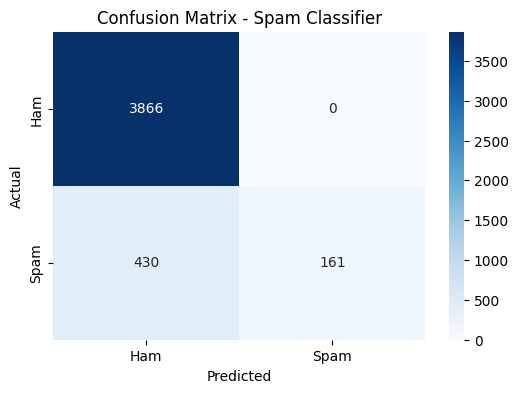

In [152]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(char, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=['Ham','Spam'],
            yticklabels=['Ham','Spam'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Spam Classifier")

plt.show()

In [154]:
import joblib
joblib.dump(multi,"email_spam.pickle")

['email_spam.pickle']

In [ ]:
model=joblib.load("email_spam.pickle")
data="Hi Nikhil27,What a show! 🏆 The first Kaggle Game Arena event of 2026 has officially concluded. From the logic of Chess to the social dynamics of Werewolf and the calculated risks of Poker, we’ve seen AI models navigate complex environments in dynamic ways.Here are the champions from the final leaderboards 👇A summary table titled From each leaderboard you can find all of the underlying datasets, game replays, model reasoning outputs and environments, open sourced for further analysis.Catch the Highlights:Missed the action? We’ve compiled all the expert commentary from Hikaru Nakamura, Nick Schulman, Doug Polk, and Liv Boeree into a single YouTube playlist.Explore The Results Here Happy Kaggling ,The Kaggle Team"

In [ ]:
def cleaning_fxn(data):
 pat="^[A-Za-z0-9]+"
 
